In [4]:
import pandas as pd 
import numpy as np 

from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report 
from sklearn .metrics import confusion_matrix 

In [6]:
df = pd.read_csv("football.csv")

In [7]:
print(df.head())

  Weather Temperature Humidity    Wind Play
0   Sunny         Hot     High    Weak   No
1   Sunny         Hot     High  Strong   No
2  Cloudy         Hot     High    Weak  Yes
3    Rain        Mild     High    Weak  Yes
4    Rain        Cool   Normal    Weak  Yes


In [8]:
df.shape

(14, 5)

In [9]:
df.info

<bound method DataFrame.info of    Weather Temperature Humidity    Wind Play
0    Sunny         Hot     High    Weak   No
1    Sunny         Hot     High  Strong   No
2   Cloudy         Hot     High    Weak  Yes
3     Rain        Mild     High    Weak  Yes
4     Rain        Cool   Normal    Weak  Yes
5     Rain        Cool   Normal  Strong   No
6   Cloudy        Cool   Normal  Strong  Yes
7    Sunny        Mild     High    Weak   No
8    Sunny        Cool   Normal    Weak  Yes
9     Rain        Mild   Normal    Weak  Yes
10   Sunny        Mild   Normal  Strong  Yes
11  Cloudy        Mild     High  Strong  Yes
12  Cloudy         Hot   Normal    Weak  Yes
13    Rain        Mild     High  Strong   No>

In [10]:
df.describe()

,Weather,Temperature,Humidity,Wind,Play
count,14,14,14,14,14
unique,3,3,2,2,2
top,Sunny,Mild,High,Weak,Yes
freq,5,6,7,8,9


In [11]:
df.isnull().sum()

Weather        0
Temperature    0
Humidity       0
Wind           0
Play           0
dtype: int64

In [12]:
df['Play'].value_counts()

Play
Yes    9
No     5
Name: count, dtype: int64

In [13]:
encoder = LabelEncoder()

df['Weather'] = encoder.fit_transform(df['Weather'])
df['Temperature'] = encoder.fit_transform(df['Temperature'])
df['Humidity'] = encoder.fit_transform(df['Humidity'])
df['Wind'] = encoder.fit_transform(df['Wind'])
df['Play'] = encoder.fit_transform(df['Play'])

In [17]:
x = df.drop('Play',axis=1)
y= df['Play']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = DecisionTreeClassifier(
    criterion='entropy'
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

1.0


In [23]:
print(confusion_matrix(y_test, y_pred))


[[1 0]
 [0 2]]


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



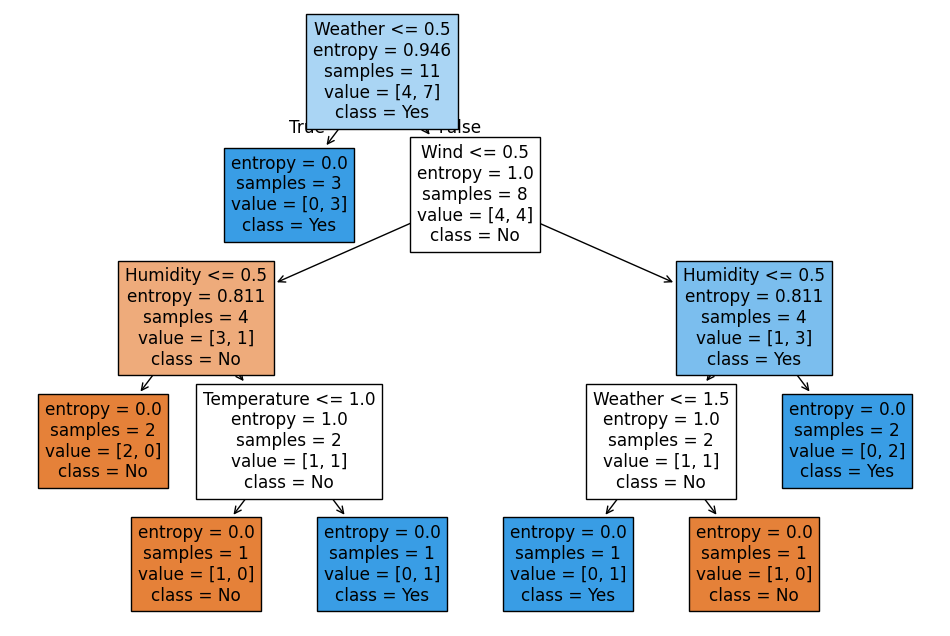

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [31]:
import pandas as pd

new_data = pd.DataFrame({
    "Weather": [2],
    "Temperature": [0],
    "Humidity": [1],
    "Wind": [1]
})

prediction = model.predict(new_data)

print(prediction)

[1]


In [32]:
import joblib

joblib.dump(model,"football_model.pkl")

['football_model.pkl']

In [33]:
model = joblib.load("football_model.pkl")

In [36]:
import pandas as pd

new_data = pd.DataFrame({
    "Weather": [0],
    "Temperature": [2],
    "Humidity": [2],
    "Wind": [0]
})

prediction = model.predict(new_data)

print(prediction)

[1]
